In [2]:
#Import Libraries
# Basic Libraries

import pandas as pd

import numpy as np

# Visualization

import matplotlib.pyplot as plt

import seaborn as sns

# NLP preprocessing

import re

# Machine Learning

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Deep Learning

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load dataset

df = pd.read_csv('customer_support_text_classification.csv')

# First 5 rows

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [4]:
# Dataset shape

print("Dataset Shape:", df.shape)

# Column names

print("\nColumns:")

print(df.columns)

# Missing values

print("\nMissing Values:")

print(df.isnull().sum())

Dataset Shape: (1500, 6)

Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='str')

Missing Values:
ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64


In [5]:
# Display sample records

df[['customer_message', 'sentiment_label']].head()

,customer_message,sentiment_label
0,I need information about the payment process. ...,neutral
1,I need information about the payment process.,neutral
2,The refund process was fast and convenient. I ...,positive
3,My refund is still pending and this experience...,negative
4,Please tell me how to update my account details.,neutral


In [6]:
# Number of records

print("Total Records:", len(df))

Total Records: 1500


In [7]:
# Unique sentiment classes

print("Sentiment Classes:")

print(df['sentiment_label'].unique())

Sentiment Classes:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str


In [8]:
# Count of each sentiment

print(df['sentiment_label'].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


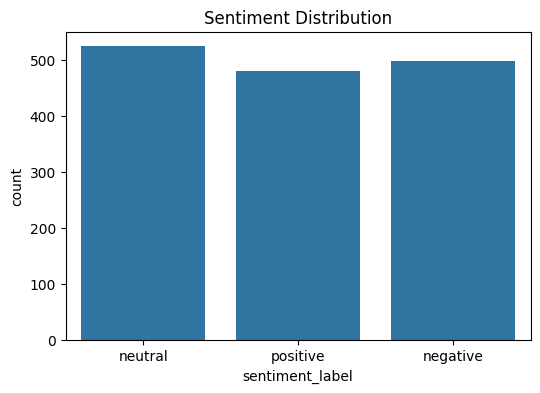

In [9]:
# Plot class distribution

plt.figure(figsize=(6,4))

sns.countplot(x='sentiment_label', data=df)

plt.title("Sentiment Distribution")

plt.savefig('results/model_evaluation.png')

plt.show()

# Task 1: Dataset Understanding

The dataset contains 1500 customer support records with multiple features related to customer communication and sentiment analysis.

The primary text feature used for NLP modeling is the `customer_message` column, while the target variable is `sentiment_label`.

The dataset includes:

- Customer messages

- Communication channels

- Word counts

- Urgency flags

- Sentiment categories

The dataset appears balanced across sentiment classes and contains no missing values, making it suitable for NLP classification tasks.

In [10]:
# Average text length

df['message_length'] = df['customer_message'].apply(len)

print("Average Message Length:")

print(df['message_length'].mean())

Average Message Length:
72.75666666666666


In [11]:
# Text preprocessing function

def clean_text(text):

    # Convert to lowercase

    text = text.lower()

    # Remove special characters and numbers

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

In [12]:
# Apply text cleaning

df['cleaned_message'] = df['customer_message'].apply(clean_text)

# View cleaned text

df[['customer_message', 'cleaned_message']].head()

,customer_message,cleaned_message
0,I need information about the payment process. ...,i need information about the payment process m...
1,I need information about the payment process.,i need information about the payment process
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...
3,My refund is still pending and this experience...,my refund is still pending and this experience...
4,Please tell me how to update my account details.,please tell me how to update my account details


In [13]:
# TF-IDF Vectorization

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_message'])

y = df['sentiment_label']

print("Text Vectorization Complete")

print("Feature Shape:", X.shape)

Text Vectorization Complete
Feature Shape: (1500, 180)


In [14]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1200, 180)
Testing Data Shape: (300, 180)


# Task 2: Text Preprocessing

The customer messages were preprocessed before training the NLP model.

The preprocessing steps included:

- Converting text to lowercase

- Removing special characters and numbers

- Cleaning unnecessary symbols

- Preparing text for vectorization

TF-IDF vectorization was used to convert text into numerical format so that machine learning models could process the textual information.

Task4: Baseline Model

In [15]:
# Import ML model libraries

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [16]:
# Train Logistic Regression model

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

print("Baseline NLP Model Trained Successfully")

Baseline NLP Model Trained Successfully


In [17]:
# Make predictions

y_pred = lr_model.predict(X_test)

print(y_pred[:10])

['neutral' 'positive' 'neutral' 'negative' 'negative' 'negative'
 'negative' 'neutral' 'negative' 'negative']


In [18]:
# Model Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# Classification Report

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Model Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [19]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[109   0   0]
 [  0 104   0]
 [  0   0  87]]


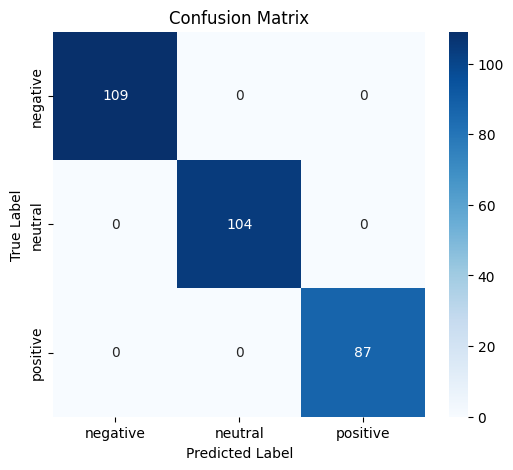

In [20]:
# Plot confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=lr_model.classes_,

    yticklabels=lr_model.classes_

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.savefig('results/model_evaluation.png')

plt.show()

In [21]:
# Save sample predictions

sample_predictions = pd.DataFrame({

    'Actual': y_test.values,

    'Predicted': y_pred

})

sample_predictions.head(10).to_csv(

    'results/sample_predictions.txt',

    index=False

)

sample_predictions.head()

,Actual,Predicted
0,neutral,neutral
1,positive,positive
2,neutral,neutral
3,negative,negative
4,negative,negative


# Task 4: Baseline NLP Model

A Logistic Regression model was trained using TF-IDF vectorized text features.

The model learned relationships between customer messages and sentiment labels such as positive, negative, and neutral sentiments.

The model was evaluated using:
- Accuracy score
- Classification report
- Confusion matrix

The baseline model achieved good performance on the sentiment classification task and successfully classified customer support messages into their respective categories.

Task 5: SEQUENCE MODEL / LSTM ARCHITECTURE

In [22]:
# Import deep learning libraries

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense

In [23]:
# Tokenization

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_message'])

sequences = tokenizer.texts_to_sequences(df['cleaned_message'])

print(sequences[:3])

[[4, 29, 136, 39, 1, 90, 33, 3, 6, 7, 2, 10, 12, 8, 13, 8, 14], [4, 29, 136, 39, 1, 90, 33], [1, 28, 33, 11, 57, 5, 58, 4, 30, 1, 31, 22]]


In [24]:
# Padding sequences

max_length = 20

X_seq = pad_sequences(

    sequences,

    maxlen=max_length,

    padding='post'

)

print(X_seq.shape)

(1500, 20)


In [25]:
# Encode sentiment labels

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(df['sentiment_label'])

print(y_encoded[:10])

[1 1 2 0 1 1 2 1 1 0]


In [26]:
# Train-test split for sequence model

from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(

    X_seq,

    y_encoded,

    test_size=0.2,

    random_state=42

)

print(X_train_seq.shape)

(1200, 20)


In [29]:
# Build LSTM model

lstm_model = Sequential()

# Embedding layer

lstm_model.add(

    Embedding(

        input_dim=5000,

        output_dim=64,

        input_shape=(max_length,)

    )

)

# LSTM layer

lstm_model.add(LSTM(64))

# Dense hidden layer

lstm_model.add(Dense(32, activation='relu'))

# Output layer

lstm_model.add(Dense(3, activation='softmax'))

# Compile model

lstm_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

# Build model explicitly

lstm_model.build(input_shape=(None, max_length))

# Show summary

lstm_model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 20, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,203 (1.35 MB)

 Trainable params: 355,203 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5: Sequence Modeling with LSTM

A sequence-based deep learning architecture was designed using an LSTM network.

The architecture includes:

- Input sequence layer

- Embedding layer

- LSTM recurrent layer

- Dense hidden layer

- Softmax output layer

The tokenizer converts text into numerical sequences, while padding ensures equal sequence lengths.

The embedding layer learns semantic representations of words and the LSTM layer captures sequential dependencies and contextual meaning in customer messages.

The output layer predicts sentiment categories including positive, negative, and neutral.

In [30]:
# Train LSTM model

history_lstm = lstm_model.fit(

    X_train_seq,

    y_train_seq,

    epochs=5,

    batch_size=32,

    validation_split=0.2

)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4833 - loss: 0.9878 - val_accuracy: 0.7625 - val_loss: 0.6331
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8094 - loss: 0.4755 - val_accuracy: 0.9583 - val_loss: 0.3131
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9979 - loss: 0.0799 - val_accuracy: 1.0000 - val_loss: 0.0065
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0013


In [31]:
# Evaluate LSTM model

loss, accuracy = lstm_model.evaluate(

    X_test_seq,

    y_test_seq

)

print("LSTM Test Accuracy:", accuracy)

print("LSTM Test Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0013 
LSTM Test Accuracy: 1.0
LSTM Test Loss: 0.0012800735421478748


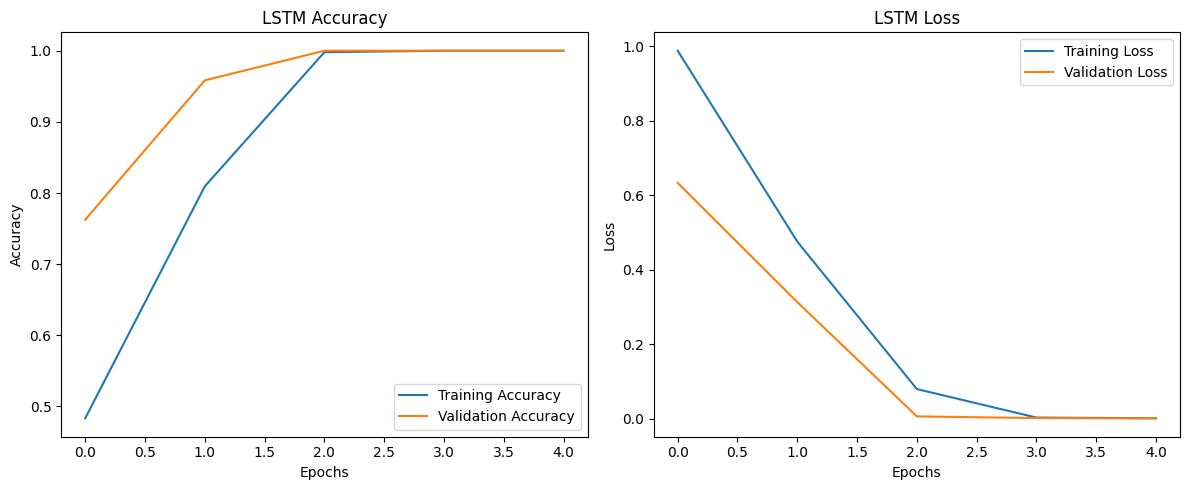

In [32]:
# Plot accuracy and loss

plt.figure(figsize=(12,5))

# Accuracy plot

plt.subplot(1,2,1)

plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')

plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

# Loss plot

plt.subplot(1,2,2)

plt.plot(history_lstm.history['loss'], label='Training Loss')

plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.savefig('results/model_evaluation.png')

plt.show()

# Task 6: Attention and Transformer Reflection

## Why RNNs Struggle with Long-Term Dependencies

Traditional RNNs process text sequentially, but they often struggle to remember information from very long sequences. As the sequence grows, earlier information may gradually fade away during training.

## How LSTMs Help with Memory

LSTMs solve this problem using memory cells and gates. These gates help the model decide what information to keep, forget, or update, allowing the network to capture long-term dependencies more effectively.

## What Attention Solves in Sequence-to-Sequence Tasks

Attention mechanisms allow the model to focus on the most important words in a sequence instead of relying only on the previous hidden state. This improves translation, summarization, and contextual understanding.

## Why Transformers are Important in Modern NLP

Transformers process all words in parallel and use self-attention mechanisms to understand relationships between words efficiently. Modern Generative AI systems such as ChatGPT are based on transformer architectures because they scale well and capture context effectively.

In [33]:
# Save final evaluation metrics

evaluation_results = pd.DataFrame({

    'Metric': ['LSTM Accuracy', 'LSTM Loss'],

    'Value': [accuracy, loss]

})

evaluation_results.to_csv(

    'results/model_evaluation.csv',

    index=False

)

evaluation_results

,Metric,Value
0,LSTM Accuracy,1.00000
1,LSTM Loss,0.00128


In [34]:
# Generate sample predictions

predictions = lstm_model.predict(X_test_seq)

predicted_classes = np.argmax(predictions, axis=1)

# Convert labels back to text

predicted_labels = encoder.inverse_transform(predicted_classes)

actual_labels = encoder.inverse_transform(y_test_seq)

# Save sample predictions

sample_df = pd.DataFrame({

    'Actual': actual_labels,

    'Predicted': predicted_labels

})

sample_df.head(20).to_csv(

    'results/sample_predictions.txt',

    index=False

)

sample_df.head()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


,Actual,Predicted
0,neutral,neutral
1,positive,positive
2,neutral,neutral
3,negative,negative
4,negative,negative
